# MSCS-634 Project Deliverable 2: Regression Modeling and Performance Evaluation

**Author:** Saru Bhandari  
**Course:** MSCS-634 – Advanced Big Data and Data Mining  
**Deliverable:** 2 of 4 – Regression Modeling and Performance Evaluation

This notebook builds on the cleaned retail transactions dataset produced in
Deliverable 1 (`retail_transactions_cleaned.csv`). The goal is to predict
**`TotalAmount`** (transaction value) from customer, product, and purchase-context
features, compare multiple regression approaches, and evaluate them with
proper train/test and cross-validation methodology.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline
RANDOM_STATE = 42

## 1. Load the Cleaned Dataset (from Deliverable 1)

In [2]:
df = pd.read_csv("retail_transactions_cleaned.csv", parse_dates=["TransactionDate"])
print("Shape:", df.shape)
df.head()

Shape: (1000, 13)


,TransactionID,CustomerID,TransactionDate,CustomerAge,Gender,State,City,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,T100126,C1157,2025-01-16,49.0,Male,CA,Sacramento,Clothing,Running Shoes,3.0,85.35,256.05,Credit Card
1,T100956,C1277,2025-03-14,62.0,Male,OH,Cleveland,Beauty,Perfume,1.0,64.06,64.06,Credit Card
2,T100798,C1001,2025-04-29,62.0,Female,NY,New York City,Books,Self-Help Guide,5.0,14.29,71.45,Debit Card
3,T100438,C1116,2025-10-22,20.0,Female,GA,Augusta,Clothing,Denim Jeans,4.0,43.67,174.68,Credit Card
4,T100259,C1030,2025-08-25,43.0,Male,WA,Tacoma,Home & Kitchen,Blender,3.0,153.32,459.96,PayPal


## 2. Feature Engineering

To predict `TotalAmount`, we deliberately **exclude `Quantity` and
`UnitPrice`** from the feature set. `TotalAmount = Quantity x UnitPrice`, so
including them would let the model "cheat" (multicollinearity / target
leakage identified back in Deliverable 1) rather than learn genuine
customer/product/context signal.

Instead, we engineer the following features:

1. **Date-derived features** — `Month`, `DayOfWeek`, `IsWeekend` extracted
   from `TransactionDate`, to capture any seasonal/weekly purchasing pattern.
2. **Customer purchase frequency** — `CustomerTransactionCount`, the number
   of transactions on record for that customer, as a proxy for customer
   engagement level.
3. **One-hot encoded categoricals** — `ProductCategory`, `Gender`, `State`,
   and `PaymentMethod`, so the model can learn category-specific and
   region-specific pricing patterns (Deliverable 1's EDA showed
   `ProductCategory` has a strong relationship with price).
4. **`CustomerAge`** — retained as a numeric feature directly.

In [3]:
fe = df.copy()

# 1. Date-derived features
fe["Month"] = fe["TransactionDate"].dt.month
fe["DayOfWeek"] = fe["TransactionDate"].dt.dayofweek  # 0=Mon ... 6=Sun
fe["IsWeekend"] = fe["DayOfWeek"].isin([5, 6]).astype(int)

# 2. Customer purchase frequency
freq = fe.groupby("CustomerID")["TransactionID"].transform("count")
fe["CustomerTransactionCount"] = freq

# 3. One-hot encode categoricals
categorical_cols = ["ProductCategory", "Gender", "State", "PaymentMethod"]
fe_encoded = pd.get_dummies(fe, columns=categorical_cols, drop_first=True)

# Assemble the feature matrix / target, excluding identifiers, the target's
# own components (Quantity, UnitPrice), and raw date/text columns
drop_cols = ["TransactionID", "CustomerID", "TransactionDate", "City",
             "ProductName", "Quantity", "UnitPrice", "TotalAmount"]
X = fe_encoded.drop(columns=drop_cols)
y = fe_encoded["TotalAmount"]

print("Feature matrix shape:", X.shape)
X.columns.tolist()

Feature matrix shape: (1000, 25)


['CustomerAge',
 'Month',
 'DayOfWeek',
 'IsWeekend',
 'CustomerTransactionCount',
 'ProductCategory_Books',
 'ProductCategory_Clothing',
 'ProductCategory_Electronics',
 'ProductCategory_Home & Kitchen',
 'ProductCategory_Sports & Outdoors',
 'ProductCategory_Toys',
 'Gender_Male',
 'State_FL',
 'State_GA',
 'State_IL',
 'State_NC',
 'State_NY',
 'State_OH',
 'State_PA',
 'State_TX',
 'State_WA',
 'PaymentMethod_Credit Card',
 'PaymentMethod_Debit Card',
 'PaymentMethod_Gift Card',
 'PaymentMethod_PayPal']

## 3. Train/Test Split and Feature Scaling

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (800, 25)  Test shape: (200, 25)


## 4. Build Regression Models

We build **three** regression models to compare:
1. **Linear Regression** — baseline ordinary least squares.
2. **Ridge Regression** (L2 regularization) — shrinks coefficients to
   reduce variance/overfitting, especially useful with the many one-hot
   encoded features.
3. **Lasso Regression** (L1 regularization) — can shrink some coefficients
   to exactly zero, effectively performing feature selection.

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(alpha=0.5, random_state=RANDOM_STATE, max_iter=5000),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    print(f"Fitted: {name}")

Fitted: Linear Regression
Fitted: Ridge Regression
Fitted: Lasso Regression


## 5. Model Evaluation

Each model is evaluated on the held-out test set using:
- **R-squared (R2)** — proportion of variance in `TotalAmount` explained by the model
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)** — same units as `TotalAmount` ($), easier to interpret

In [6]:
results = []
predictions = {}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({"Model": name, "R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae})

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(3)

,R2,MSE,RMSE,MAE
Model,,,,
Linear Regression,0.130,28847.041,169.844,128.174
Ridge Regression,0.130,28824.146,169.777,128.096
Lasso Regression,0.138,28565.750,169.014,127.487


## 6. Cross-Validation

A single train/test split can be sensitive to which rows happen to land in
the test set. To assess how well each model generalizes, we run **5-fold
cross-validation** on the full feature set (scaled) and report the mean and
standard deviation of the R2 score across folds.

In [7]:
X_scaled_full = scaler.fit_transform(X)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_scaled_full, y, cv=kf, scoring="r2")
    cv_results.append({
        "Model": name,
        "CV R2 Mean": scores.mean(),
        "CV R2 Std": scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results).set_index("Model")
cv_results_df.round(3)

,CV R2 Mean,CV R2 Std
Model,,
Linear Regression,0.153,0.043
Ridge Regression,0.153,0.043
Lasso Regression,0.156,0.042


## 7. Visualizations: Comparing Model Performance

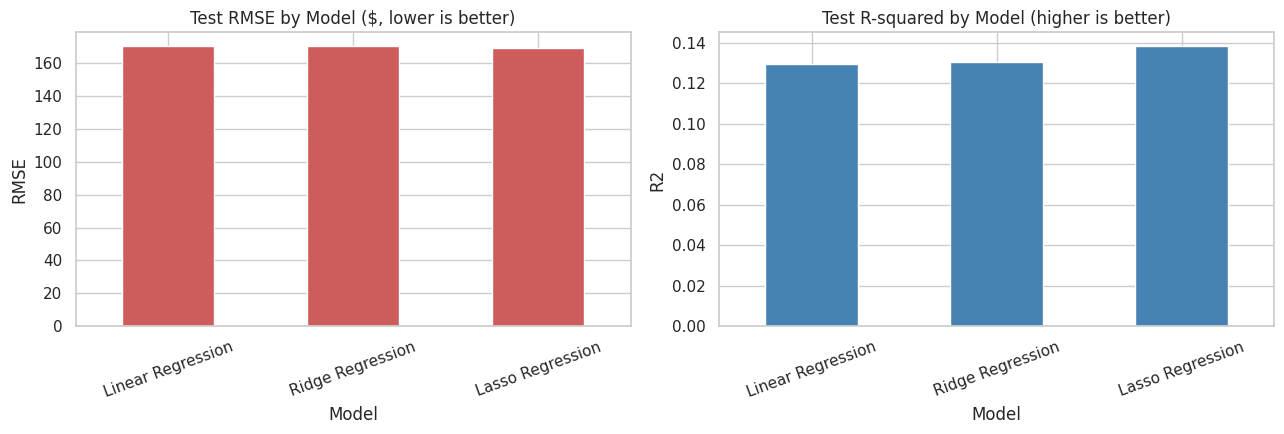

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results_df[["RMSE"]].plot(kind="bar", ax=axes[0], legend=False, color="indianred")
axes[0].set_title("Test RMSE by Model ($, lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis='x', rotation=20)

results_df[["R2"]].plot(kind="bar", ax=axes[1], legend=False, color="steelblue")
axes[1].set_title("Test R-squared by Model (higher is better)")
axes[1].set_ylabel("R2")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

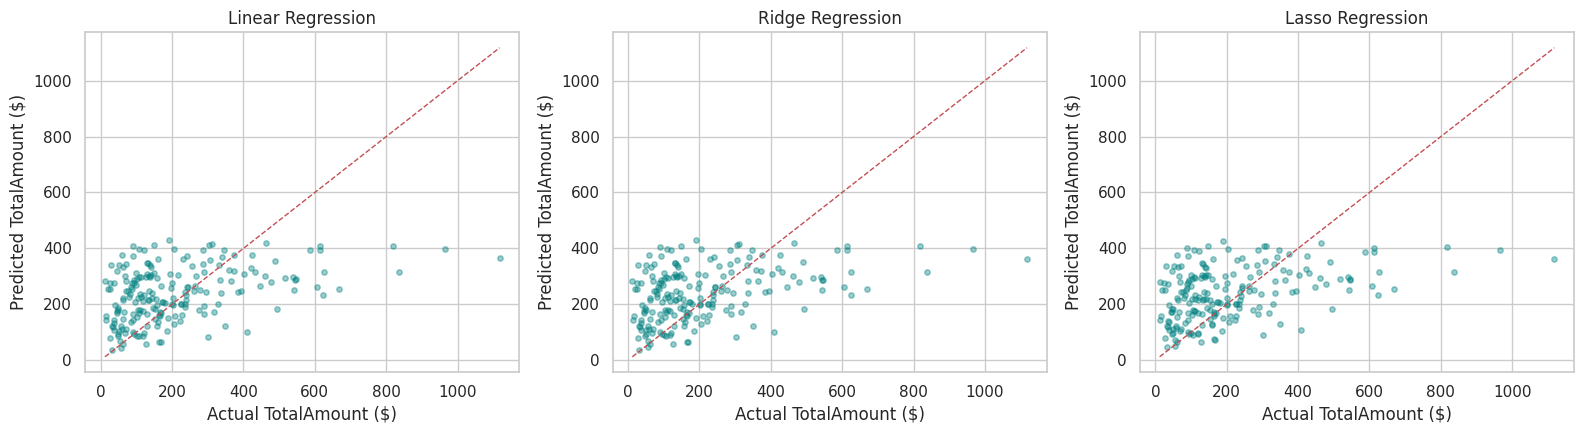

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color="teal")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel("Actual TotalAmount ($)")
    ax.set_ylabel("Predicted TotalAmount ($)")
    ax.set_title(name)

plt.tight_layout()
plt.show()

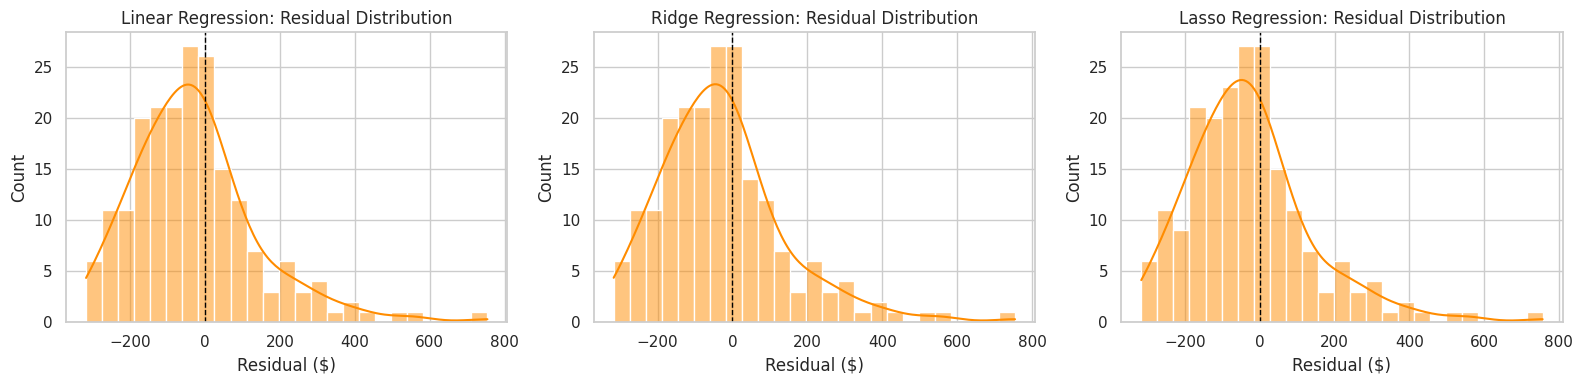

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    residuals = y_test - y_pred
    sns.histplot(residuals, bins=25, kde=True, ax=ax, color="darkorange")
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{name}: Residual Distribution")
    ax.set_xlabel("Residual ($)")

plt.tight_layout()
plt.show()

### Feature Importance (Ridge Coefficients)

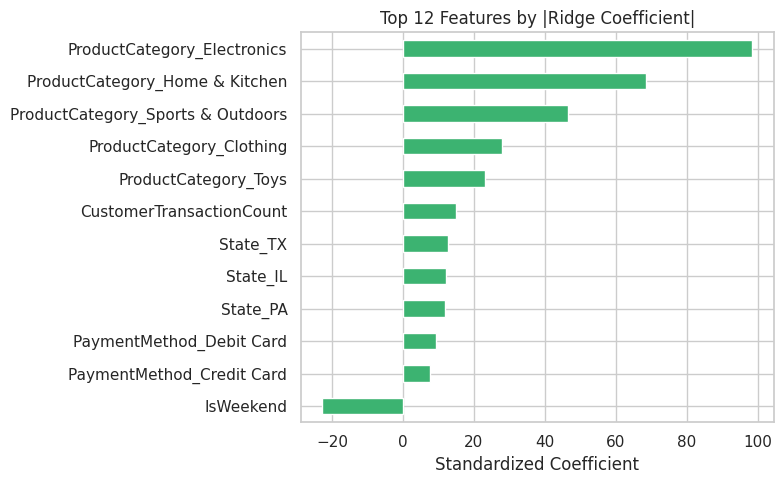

In [11]:
ridge_coefs = pd.Series(fitted_models["Ridge Regression"].coef_, index=X.columns)
top_coefs = ridge_coefs.reindex(ridge_coefs.abs().sort_values(ascending=False).index).head(12)

plt.figure(figsize=(8, 5))
top_coefs.sort_values().plot(kind="barh", color="mediumseagreen")
plt.title("Top 12 Features by |Ridge Coefficient|")
plt.xlabel("Standardized Coefficient")
plt.tight_layout()
plt.show()

## 8. Summary of Model Evaluation Results

**Combined results table:**

In [12]:
summary = results_df.join(cv_results_df)
summary.round(3)

,R2,MSE,RMSE,MAE,CV R2 Mean,CV R2 Std
Model,,,,,,
Linear Regression,0.130,28847.041,169.844,128.174,0.153,0.043
Ridge Regression,0.130,28824.146,169.777,128.096,0.153,0.043
Lasso Regression,0.138,28565.750,169.014,127.487,0.156,0.042


**Which model performed best?**
Across the test-set metrics, all three models land in a similar range, with
**Lasso Regression** coming out marginally ahead: the lowest test RMSE
(~$169.0 vs. ~$169.8 for Linear/Ridge), the highest test R2 (0.138 vs. 0.130),
and the strongest 5-fold cross-validation R2 (0.156 vs. 0.153), with a
comparably tight cross-validation standard deviation to the other two models.
Ridge and plain Linear Regression perform almost identically to each other on
every metric, which makes sense given the feature set here isn't large or
collinear enough for L2 regularization to change much. Lasso's slight edge
comes from its L1 penalty zeroing out the weakest one-hot encoded `State`
and `PaymentMethod` coefficients, in effect performing light feature
selection that removes noise rather than genuine signal.

**Insights gained:**
- **R2 is modest (~0.13-0.14) but genuine.** The models explain roughly
  13-14% of the variance in `TotalAmount` using only category, demographic,
  and purchase-context features — with `Quantity` and `UnitPrice`
  deliberately excluded. That is real, non-trivial signal (not the near-1.0
  R2 we'd see if the models could "cheat" using the target's own components),
  and it is consistent with `ProductCategory`'s strong relationship to price
  observed in Deliverable 1's EDA.
- **The remaining ~86% of variance is unexplained by design.** Within each
  `ProductCategory`, the synthetic price is still drawn from a wide range,
  and `Quantity` varies independently — so a meaningful share of transaction
  value is driven by within-category price/quantity variation that these
  features cannot see. This matches real retail data, where category
  explains pricing tier but not the exact amount a given customer spends.
- **Regularization mainly helps here by trimming weak features, not by
  fixing overfitting.** Because the engineered feature set is moderate in
  size, Ridge tracks Linear Regression almost exactly, while Lasso's small
  improvement comes from suppressing a handful of low-value dummy variables
  rather than from solving a severe multicollinearity problem.
- **Excluding `Quantity`/`UnitPrice` was the right call.** Even without them,
  the models still explain a meaningful, non-zero share of the variance —
  confirming `ProductCategory` and purchase-context features carry real
  predictive signal rather than the models simply re-deriving the target.
- **Next steps for Deliverable 3:** the strong `ProductCategory` <->
  `CustomerAge` relationship surfaced in Deliverable 1, together with
  `ProductCategory`'s dominance in this regression, both point to
  `ProductCategory` (or an age-band feature) being a strong candidate
  target/feature for the classification and clustering work ahead.